In [1]:
import pandas as pd
import numpy as np
import re
import src_any_abogados_fuzzymerge_df_er_v1_sec as src
import src_any_abogados_numbersmerge_df_er_v1_sec as src2
import src_any_abogados_emailmerge_df_er_v1_sec as src3
import src_any_abogados_test_df_er_v1_sec as src4
import src_email_abogados_webcrawling_df_er_v1_sec as src5

In [2]:
pd.set_option("display.max_rows", None)

In [3]:
def remove_empty_columns(df):

    df_aux = df.copy()
    empty_columns = list(df_aux.columns[df_aux.isna().mean() == 1])   # Almacena en una lista las columnas que están totalmente vacias
    if "Unnamed: 0" in df_aux.columns:
        empty_columns.append("Unnamed: 0")
    df_aux = df_aux.drop(columns=empty_columns)
    return df_aux

In [4]:
#Lectura de tablas
df_gm_o = pd.read_csv("datasets/Dataset_GM_PR.csv")
df_ca_o = pd.read_csv("datasets/datos_abogados.csv") 
df_naics_o = pd.read_csv("datasets/NAICS_Puerto Rico.csv")

df_gm_o = remove_empty_columns(df_gm_o)
df_ca_o = remove_empty_columns(df_ca_o)
df_naics_o = remove_empty_columns(df_naics_o)

df_gm_o["Email"] = df_gm_o["Email"].str.strip().replace(["Not available"], np.nan)

# Agregar columna que indique de dónde viene el registro
df_gm_o["dataset"] = "gm"
df_ca_o["dataset"] = "ca"
df_naics_o["dataset"] = "naics"

In [5]:
#Agregar columna "is Firm" para diferenciar Firma de Abogados
df_gm_o['is Firm'] = df_gm_o['Name'].apply(lambda x: bool(re.search(src.pattern_firma, str(x), flags=re.IGNORECASE)))

In [6]:
#DataFrame que almacena los registros que son firmas
df_gm_firmas = df_gm_o[df_gm_o["is Firm"]]

#DataFrame filtrado y almacena los registro que son abogados
df_gm_o = df_gm_o[~df_gm_o["is Firm"]]

#Normalización de nombres
df_gm_o["Clean_Name"] = df_gm_o["Name"].apply(lambda x: src.name_normalized(x)).str.lower()
df_ca_o["FULL NAME"] = df_ca_o["FULL NAME"].apply(lambda x: src.name_normalized(x)).str.lower()
df_naics_o["Name_N"] = df_naics_o["Name_N"].apply(lambda x: src.name_normalized(x)).str.lower()

#Reset index
df_gm_o = df_gm_o.reset_index(drop=True)
df_ca_o = df_ca_o.reset_index(drop=True)
df_naics_o = df_naics_o.reset_index(drop=True)

In [7]:
# Columnas importantes: Name, city, state_name, Address, Website,Phone,Google_category,Type,Email,Specialization,Education,ExperiencE
# Columnas a Analizar: zip, state_id, Orig Specialization
# NO Columnas importantes: Google_URL, population,Google_rank,Google_opinions,Google_category,Processed,Name AI

#df_gm_o.isna().mean()

In [8]:
# Columnas importantes: FULL NAME', 'FNAME', 'LNAME
# Columnas a Analizar: 
# NO Columnas importantes:

#df_ca_o.isna().mean()

In [9]:
# Columnas importantes: FULL NAME', 'FNAME', 'LNAME
# Columnas a Analizar: 
# NO Columnas importantes:

#df_naics_o.isna().mean()

In [10]:
df_ca_o = src2.combine_columns_by_priority(df_ca_o,["tel_celular","tel_residencial","tel_oficina","otro"],"telefono")
df_naics_o = src2.combine_columns_by_priority(df_naics_o,["Mobile phone","Direct Phone Number"], "phone")

In [11]:
df_ca_o["telefono"] = df_ca_o["telefono"].apply(lambda phone: src2.normalized_phone(str(phone)) if pd.notnull(phone) else None)
df_naics_o["phone"] = df_naics_o["Mobile phone"].apply(lambda phone: src2.normalized_phone(str(phone)) if pd.notnull(phone) else None)

# Merge por coincidencia exacta de número de contacto

No se obtuvo ninguna coincidencia exacta por número de teléfono entre los 3 datasets.
Se obtuvo 3 coincidencias exactas entre los datasets del colegio de abogados y naics

In [12]:
#Merge entre gm y ca
df_gm_y_df_ca = src2.merge_by_contact_number(df_gm_o, df_ca_o, "Phone", "telefono", "Clean_Name", "FULL NAME")
print(df_gm_y_df_ca[["Clean_Name","FULL NAME","Phone","telefono","score"]].head())


                Clean_Name                FULL NAME    Phone telefono  score
0     luis mercado hidalgo     luis mercado hidalgo  4537437  4537437      1
1   lutgardo acevedo lopez   lutgardo acevedo lopez  4669845  4669845      1
2         edil quiles seda         edil quiles seda  8962727  8962727      1
3  lizandra torres rosario  lizandra torres rosario  6392632  6392632      1
4  vanessa gordils vazquez  vanessa gordils vazquez  8085036  8085036      1


In [13]:
#Merge entre gm y naics
df_gm_y_df_naics = src2.merge_by_contact_number(df_gm_o, df_naics_o, "Phone", "phone", "Clean_Name", "Name_N")
print(df_gm_y_df_naics[["Clean_Name","Name_N","Phone","phone","score"]].head())

               Clean_Name                  Name_N    Phone    phone  score
0       tus documentos pr    roberto velez medina  8507164  8507164      0
1  julian rivera aspinall  julian rivera aspinall  3600094  3600094      1
2         carlos lamoutte         carlos lamoutte  6886036  6886036      1


In [14]:
#Merge entre ca y naics  -->> **  # Salen 3 registros coincidencia exacta **
df_ca_y_df_naics = src2.merge_by_contact_number(df_ca_o, df_naics_o, "telefono", "phone", "FULL NAME", "Name_N")
print(df_ca_y_df_naics[["FULL NAME","Name_N","telefono","phone","score"]].head())               

                 FULL NAME                           Name_N telefono    phone  \
0     esteban mujica cotto             esteban mujica cotto  5184101  5184101   
1  josue castellanos otero  josue emanuel castellanos otero  2995935  2995935   
2  francisco garcia garcia                 francisco garcia  3984898  3984898   

   score  
0      1  
1      0  
2      0  


In [15]:
#Merge COMPLETO
df_merged_full = src2.merge_by_contact_number(df_gm_y_df_ca, df_naics_o, "Phone", "phone", "FULL NAME", "Name_N")
print(df_merged_full[["Clean_Name","FULL NAME","Phone","telefono","score"]].head())

Empty DataFrame
Columns: [Clean_Name, FULL NAME, Phone, telefono, score]
Index: []


# Merge por coincidencia exacta de Email

In [16]:
#Merge entre gm y ca    -->> ** 5 coincidencias exactas **
df_gm_y_df_ca = src3.merge_by_email(df_gm_o, df_ca_o, "Email", "correo", "Clean_Name", "FULL NAME")
print(df_gm_y_df_ca[["Clean_Name","FULL NAME","Email","correo","score"]].head())

#Merge entre gm y naics -->> NO COINCIDENCIAS
df_gm_y_df_naics = src3.merge_by_email(df_gm_o, df_naics_o, "Email", "Email Address", "Clean_Name", "Name_N")
print(df_gm_y_df_naics[["Clean_Name","Name_N","Phone","phone","score"]].head())

#Merge entre ca y naics  -->> ** 5 coincidencias exactas
df_ca_y_df_naics = src3.merge_by_email(df_ca_o, df_naics_o, "correo", "Email Address", "FULL NAME", "Name_N")
print(df_ca_y_df_naics[["FULL NAME","Name_N","correo","Email Address","score"]].head())               

#Merge COMPLETO   -->> NO COINCIDENCIAS
df_merged_full = src3.merge_by_email(df_gm_y_df_ca, df_naics_o, "correo", "Email Address", "FULL NAME", "Name_N")
print(df_merged_full[["Clean_Name","FULL NAME","Phone","telefono","score"]].head())

               Clean_Name               FULL NAME  \
0  lutgardo acevedo lopez  lutgardo acevedo lopez   
1        edil quiles seda        edil quiles seda   
2       omar bonet tirado       omar bonet tirado   
3       onix cintron baez       onix cintron baez   
4     beatriz cay vazquez     beatriz cay vazquez   

                         Email                       correo  score  
0        lacevedolaw@gmail.com        lacevedolaw@gmail.com      1  
1       quilesseda@hotmail.com       quilesseda@hotmail.com      1  
2          omar.bonet@capr.org          omar.bonet@capr.org      1  
3   onix.cintron.law@gmail.com   onix.cintron.law@gmail.com      1  
4  beatrizcayvazquez@gmail.com  beatrizcayvazquez@gmail.com      1  
Empty DataFrame
Columns: [Clean_Name, Name_N, Phone, phone, score]
Index: []
               FULL NAME                 Name_N                    correo  \
0   jose gonzalez rivera          jose gonzalez   jrg@gonzalezmorales.com   
1  ricardo garcia negron  ricardo ga

# Coincidencias exactas por Nombre

In [17]:
#Merge entre gm y ca    -->> ** 5 coincidencias exactas **
df_gm_y_df_ca = src3.merge_by_email(df_gm_o, df_ca_o, "Clean_Name", "FULL NAME", "Clean_Name", "FULL NAME")
print(df_gm_y_df_ca[["Clean_Name","FULL NAME","score"]].head())

#Merge entre gm y naics -->> ** 5 coincidencias exactas **
df_gm_y_df_naics = src3.merge_by_email(df_gm_o, df_naics_o, "Clean_Name", "Name_N", "Clean_Name", "Name_N")
print(df_gm_y_df_naics[["Clean_Name","Name_N","score"]].head())

#Merge entre ca y naics  -->> ** 5 coincidencias exactas **
df_ca_y_df_naics = src3.merge_by_email(df_ca_o, df_naics_o, "FULL NAME", "Name_N", "FULL NAME", "Name_N")
print(df_ca_y_df_naics[["FULL NAME","Name_N","score"]].head())               

#Merge COMPLETO   -->> NO HAY CONCIDENCIAS  
df_merged_full = src3.merge_by_email(df_gm_y_df_ca, df_naics_o, "Clean_Name", "Name_N", "FULL NAME", "Name_N")
print(df_merged_full[["Clean_Name","FULL NAME","score"]].head())

               Clean_Name               FULL NAME  score
0    luis mercado hidalgo    luis mercado hidalgo      1
1         jose cruz ellis         jose cruz ellis      1
2  lutgardo acevedo lopez  lutgardo acevedo lopez      1
3   jorge hernandez lopez   jorge hernandez lopez      1
4   angela oquendo negron   angela oquendo negron      1
          Clean_Name             Name_N  score
0  felipe soto ortiz  felipe soto ortiz      1
1      jaime ruberte      jaime ruberte      1
2    gilberto oliver    gilberto oliver      1
3       jose benitez       jose benitez      1
4    francisco ramos    francisco ramos      1
                     FULL NAME                       Name_N  score
0  veronica gonzalez rodriguez  veronica gonzalez rodriguez      1
1         edwin rivera cintron         edwin rivera cintron      1
2            alba lopez arzola            alba lopez arzola      1
3       fernando collazo valle       fernando collazo valle      1
4      isabel ruberte figueroa      isabe

# Merge por coincidencias difusas de nombre

In [18]:
df_gm = df_gm_o[["Clean_Name"]]
df_ca = df_ca_o[["FULL NAME"]]
df_naics = df_naics_o[["Name_N"]]

In [19]:
matches = src.find_fuzzy_matches(df_ca, df_naics,"FULL NAME", "Name_N", 85)

In [20]:
from sklearn.model_selection import train_test_split

# Suponiendo que ya tienes df_resultado = find_fuzzy_matches(...)

df_train, df_test = train_test_split(
    matches,
    test_size=0.2,
    stratify=matches["actual"],  # para mantener proporción 0/1
    random_state=42
)

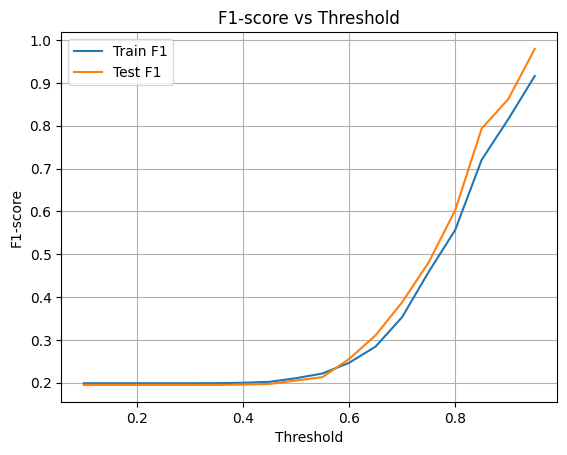

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores_train = []
f1_scores_test = []

for t in thresholds:
    df_train_eval = src4.test2(df_train, t)
    df_test_eval = src4.test2(df_test, t)
    f1_scores_train.append(f1_score(df_train_eval["actual"], df_train_eval["predicted"]))
    f1_scores_test.append(f1_score(df_test_eval["actual"], df_test_eval["predicted"]))

plt.plot(thresholds, f1_scores_train, label="Train F1")
plt.plot(thresholds, f1_scores_test, label="Test F1")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold")
plt.legend()
plt.grid(True)
#plt.show()

In [22]:
evaluacion = src4.test2(matches, 0.9)

In [23]:
from sklearn.metrics import confusion_matrix, f1_score

# Suponiendo que tienes:
def metrics(eval):
    y_true = eval["actual"]
    y_pred = eval["predicted"]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # F1-score
    f1 = f1_score(y_true, y_pred)

    # Mostrar resultados
    print(f"TP: {tp}")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"F1-score: {f1:.2f}")


In [24]:
metrics(evaluacion)

TP: 123
TN: 968
FP: 63
FN: 4
F1-score: 0.79


In [25]:
predicted1 = evaluacion[evaluacion["predicted"] == 1]
predicted1.reset_index(drop=True, inplace=True)
predicted1.to_csv("datasets/predicted1.csv")

predicted0 = evaluacion[evaluacion["predicted"] == 0]
predicted0.reset_index(drop=True, inplace=True)
predicted0.to_csv("datasets/predicted0.csv")

evaluacion.to_csv("datasets/TODO.csv")

In [26]:
actual1 = evaluacion[evaluacion["actual"] == 1]
actual1.reset_index(drop=True, inplace=True)
actual1.to_csv("datasets/actual1.csv")

actual0 = evaluacion[evaluacion["actual"] == 0]
actual0.reset_index(drop=True, inplace=True)
actual0.to_csv("datasets/actual0.csv")

In [27]:
#------------------------- Merge entre COLEGIO DE ABOGADOS y NAICS --------------------------------#

In [28]:
# Merge de coincidencias difusas entre colegio e abogados y naics

step1 = predicted1.merge(df_ca_o, left_on="name1", right_on="FULL NAME", how="inner")
final_step = step1.merge(df_naics_o, left_on="name2", right_on="Name_N", how="inner")
columnas_principales = ["FULL NAME", "Name_N"]
otras_columnas = [col for col in final_step.columns if col not in columnas_principales]
final_step = final_step[columnas_principales + otras_columnas]
final_step_copy = final_step.copy()
final_step.drop(columns=["name1","name2","score","actual","predicted"], inplace=True)
final_step = final_step.rename(columns={
    "FULL NAME": "name_colegio_abogados",
    "Name_N": "name_naics"
})
final_step.to_csv("datasets/merge_colegio-abogados_naics.csv")



In [29]:
final_ff = final_step_copy[(final_step_copy["actual"] == 1) & (final_step_copy["predicted"] == 1)]

final_ff.head()

,FULL NAME,Name_N,name1,name2,score,actual,predicted,FNAME,LNAME,colegiacion,...,Company State,Company Zip Code,Company Country,Full Address,Number of Locations,Query Name,Subject 2 New,Body 2 New,dataset_y,phone
0,jose soto,jose soto,jose soto,jose soto,100.0,1,1,Jose,Soto,5040.0,...,Puerto Rico,901,United States,"151 San Franisco St Ste 200, San Juan, Puerto ...",2.0,naics-541110puertorico,NaN,NaN,naics,None
1,katia recio curet,katia recio curet,katia recio curet,katia recio curet,100.0,1,1,Katia,Recio Curet,19259.0,...,Puerto Rico,918,United States,"270 Munoz Rivera, San Juan, Puerto Rico, 00918...",9.0,naics-541110puertorico,NaN,NaN,naics,None
2,samuel cespedes sabater,samuel cespedes sabater,samuel cespedes sabater,samuel cespedes sabater,100.0,1,1,Samuel,Cespedes Sabater,10905.0,...,Puerto Rico,918,United States,"270 Munoz Rivera, San Juan, Puerto Rico, 00918...",9.0,naics-541110puertorico,NaN,NaN,naics,6888994
3,jaime sanabria montanez,jaime sanabria montanez,jaime sanabria montanez,jaime sanabria montanez,100.0,1,1,Jaime,Sanabria Montañez,15716.0,...,Valencia,46002,Spain,"B · 1 1, Valencia, Valencia, 46002, Spain",4.0,naics-541110puertorico,NaN,NaN,naics,5043004
4,adriana perez rentas,adriana perez rentas,adriana perez rentas,adriana perez rentas,100.0,1,1,Adriana,Perez Rentas,19803.0,...,Greater London,EC1A 4HT,United Kingdom,"160 Aldersgate St, London, Greater London, EC1...",127.0,naics-541110puertorico,NaN,NaN,naics,None


In [30]:
nombre_a = "name1"
final_step_col = final_ff[[nombre_a]]

In [31]:
matches_gm_final_step1 = src.find_fuzzy_matches(df_gm, final_step_col ,"Clean_Name", nombre_a, 81)
eval_matches_gm_final_step1 = src4.test2(matches_gm_final_step1, 0.8)


tt = matches_gm_final_step1.merge(final_ff, left_on="name2",right_on=nombre_a,how="inner")
#tt = tt.drop(columns=["score","actual_x"])
tt.to_csv("datasets/merge_total.csv")
tt.head()

,name1_x,name2_x,score_x,actual_x,FULL NAME,Name_N,name1_y,name2_y,score_y,actual_y,...,Company State,Company Zip Code,Company Country,Full Address,Number of Locations,Query Name,Subject 2 New,Body 2 New,dataset_y,phone
0,ivan torres rodriguez,yarimar torres rodriguez,84.444444,0,yarimar torres rodriguez,yarimar torres rodriguez,yarimar torres rodriguez,yarimar torres rodriguez,100.000000,1,...,Puerto Rico,908,United States,"PO Box 9021, San Juan, Puerto Rico, 00908, Uni...",1.0,naics-541110puertorico,NaN,NaN,naics,None
1,carol colon santiago,carol sosa santiago,82.051282,0,carol sosa santiago,carlos santiago,carol sosa santiago,carlos santiago,88.235294,1,...,Puerto Rico,936,United States,"PO Box 367189, San Juan, Puerto Rico, 00936, U...",1.0,naics-541110puertorico,NaN,NaN,naics,3648080
2,eric santiago rivera,miguel santiago rivera,80.952381,0,miguel santiago rivera,miguel santiago rivera,miguel santiago rivera,miguel santiago rivera,100.000000,1,...,Puerto Rico,901,United States,"53 Calle Palmeras Ste 1601, San Juan, Puerto R...",3.0,naics-541110puertorico,NaN,NaN,naics,5233436
3,evelyn garcia lopez,rafael garcia lopez,78.947368,0,rafael garcia lopez,rafael garcia lopez,rafael garcia lopez,rafael garcia lopez,100.000000,1,...,Texas,79401,United States,"1402 Crickets Ave, Lubbock, Texas, 79401, Unit...",11.0,naics-541110puertorico,NaN,NaN,naics,None
4,yanira colon garcia,yadira colon alicea,78.947368,0,yadira colon alicea,yadira colon alicea,yadira colon alicea,yadira colon alicea,100.000000,1,...,Puerto Rico,908,United States,"PO Box 9134, San Juan, Puerto Rico, 00908, Uni...",3.0,naics-541110puertorico,NaN,NaN,naics,None


In [32]:
def pruebas(df1, df2, name1, name2, threshold):
    matches = src.find_fuzzy_matches(df1, df2,name1, name2, threshold)
    evaluacion = src4.test(matches)

    y_true = evaluacion["actual"]
    y_pred = evaluacion["predicted"]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # F1-score
    f1 = f1_score(y_true, y_pred)

    print(f"TP: {tp}")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"F1-score: {f1:.2f}")

    return tn, fp, fn, tp, f1

In [33]:
# V3

# Webcrawling

In [34]:

resultado = src5.extraer_emails_desde_web(df=final_step, columna_url='Website')
resultado.to_csv("datasets/correos_con_todos_limpios.csv", index=False)



Procesando jose soto - www.impetusgrouppr.com
Procesando katia recio curet - www.mcvpr.com
Procesando samuel cespedes sabater - www.mcvpr.com
Procesando jaime sanabria montanez - www.ecija.com
Procesando adriana perez rentas - www.dlapiper.com
Procesando juan acevedo cruz - www.jracevedo.com
Procesando eduardo tamargo motroni - www.ferraiuoli.com
Procesando glorimar acevedo cruz - www.littler.com
Procesando fernando van derdys - www.reichardescalera.com


KeyboardInterrupt: 

In [ ]:
resultado.head()

,name_colegio_abogados,name_naics,FNAME,LNAME,colegiacion,rua,correo,tel_residencial,tel_oficina,tel_celular,...,Full Address,Number of Locations,Query Name,Subject 2 New,Body 2 New,dataset_y,phone,emails,emails_todos,email_principal
0,jose soto,jose soto,Jose,Soto,5040.0,3729.0,NaN,NaN,NaN,NaN,...,"151 San Franisco St Ste 200, San Juan, Puerto ...",2.0,naics-541110puertorico,NaN,NaN,naics,None,[dh@impetusgrouppr.com],dh@impetusgrouppr.com,dh@impetusgrouppr.com
1,katia recio curet,katia recio curet,Katia,Recio Curet,19259.0,18078.0,NaN,NaN,NaN,NaN,...,"270 Munoz Rivera, San Juan, Puerto Rico, 00918...",9.0,naics-541110puertorico,NaN,NaN,naics,None,[],,None
2,samuel cespedes sabater,samuel cespedes sabater,Samuel,Cespedes Sabater,10905.0,8797.0,NaN,NaN,NaN,NaN,...,"270 Munoz Rivera, San Juan, Puerto Rico, 00918...",9.0,naics-541110puertorico,NaN,NaN,naics,6888994,[],,None
3,jaime sanabria montanez,jaime sanabria montanez,Jaime,Sanabria Montañez,15716.0,14260.0,NaN,NaN,NaN,NaN,...,"B · 1 1, Valencia, Valencia, 46002, Spain",4.0,naics-541110puertorico,NaN,NaN,naics,5043004,"[guenosinfo@ecija.com, info@ecija.com]",guenosinfo@ecija.com; info@ecija.com,guenosinfo@ecija.com
4,adriana perez rentas,adriana perez rentas,Adriana,Perez Rentas,19803.0,19830.0,NaN,NaN,NaN,NaN,...,"160 Aldersgate St, London, Greater London, EC1...",127.0,naics-541110puertorico,NaN,NaN,naics,None,[],,None
